# Global Sales Exploratory Data Analysis

This notebook performs an end-to-end exploratory data analysis on a global sales dataset.

The analysis answers five business questions:
1. **Company performance** - What are the key revenue, profit, and sales volume metrics?
2. **Revenue & profitability** — Which categories, countries, and channels drive the most profit?
3. **Product popularity** — Which products sell best, and does this vary by geography or channel?
4. **Operational efficiency** — How long does order-to-ship take, and where are the bottlenecks?
5. **Sales dynamics & seasonality** — How has revenue trended, and are there seasonal patterns?

**Dataset:** Three relational tables — orders, products, countries  
**Stack:** Python, pandas, matplotlib, seaborn  
**Period:** 2010–2017

> **To run:** Place `events.csv`, `products.csv`, and `countries.csv` in your
> working directory and update the file paths in Section 2 below.

# 1. Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="darkgrid")

# 2. Data extract

In [ ]:
from google.colab import drive
import zipfile

# Mount Drive to get access to the files
drive.mount("/content/drive", force_remount=True)

# Update the path to match the path to your dataset
# %cd /content/drive/


# with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
#     zip_ref.extractall("dataset_extracted")

# Update the paths to match your datasets
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
display(countries, events, products)

Mounted at /content/drive
/content/drive/My Drive/Career & Education/Mate.DA course/ETL files


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


# 3. Data overview

In [ ]:
display(countries, countries.info())
display(events, events.info())
display(products, products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


None

## Data overview summary

**Countries**:
* name - name of the country (str)
* alpha-2 - country's alpha-2 code (str)
* alpha-3 - country's alpha-3 code (str)
* region - regin which the country belongs to (str)
* sub-region - sub-regin which the country belongs to (str)


249 rows × 5 columns. There are missing values. Data types are correct.



**Events**:

* Order ID - order unique identifier (int64)
* Order Date - date of the order (str)
* Ship Date - date when a product was dispatched (str)
* Order Priority - priority of the order (str)
* Country Code - country alpha_3 code (str)
* Product ID - identifier of a product (int64)
* Sales Channel - channel through which a product was sold (str)
* Units Sold - number of products sold (float64)
* Unit Price - price of one unit of a product for purchase (float64)
* Unit Cost - cost of one unit of a product for the company (float64)

1330 rows × 10 columns. There are missing values. Incorrect data types: Order Date, Ship Date.


**Products**:

* id - (int64)
* item_type - (str)

12 rows × 2 columns. No mising values. Data types are correct.


### Next actions


1. Connect tables. Key fields to connect Events table and Countries table: left='Country Code', right='alpha-3'. Key fields to connect Events table and Products table: left='Product ID', right='id'
2. There is a need to rename columns in all tables to bring everything to one name format for convenience
3. Handle missing values in Events and Countries tables
4. Fix data types in Events table (Order Date, Ship Date)


# 4. Data cleaning

In [ ]:
# Rename columns so the fields match in different datasets
countries = countries.rename(
    columns={
        "alpha-2": "alpha_2",
        "alpha-3": "alpha_3",
        "sub-region": "sub_region",
        "name": "country_name",
    }
)

events = events.rename(
    columns={
        "Order ID": "order_id",
        "Order Date": "order_date",
        "Ship Date": "ship_date",
        "Order Priority": "order_priority",
        "Country Code": "country_code",
        "Product ID": "product_id",
        "Sales Channel": "sales_channel",
        "Units Sold": "units_sold",
        "Unit Price": "unit_price",
        "Unit Cost": "unit_cost",
    }
)

products = products.rename(columns={"item_type": "product_category"})

display(countries, events)

,country_name,alpha_2,alpha_3,region,sub_region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


## 4.1 Handle missing values

In [ ]:
# countries table

percentage_of_missing_countries_values = (
    countries.isna().sum(axis=0) / countries.shape[0] * 100
)

rows_with_missing_values = countries[countries.isna().any(axis=1)]
print("rows_with_missing_values", rows_with_missing_values)

# Percentage os missing values is very small (almost 0), so it would be safe to drop such values.
# But there are 2 countries that have missing values: Antarctica and Namibia. For Antarctica the missing values are expected as it's not part of any political or economic region/sub-region. For Namibia there is a missing alpha_2 code, which is not critical since there is alpha_3 field which will be used for tables merge.
# Thus, decided to fill in missing values and preserve these countries for further analysis.
countries.loc[countries["alpha_3"] == "NAM", "alpha_2"] = "NA"
countries.loc[countries["alpha_3"] == "ATA", ["region", "sub_region"]] = [
    "Antarctica",
    "Antarctica",
]

countries.info()

rows_with_missing_values     country_name alpha_2 alpha_3  region          sub_region
8     Antarctica      AQ     ATA     NaN                 NaN
153      Namibia     NaN     NAM  Africa  Sub-Saharan Africa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  249 non-null    object
 1   alpha_2       249 non-null    object
 2   alpha_3       249 non-null    object
 3   region        249 non-null    object
 4   sub_region    249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# events table

percentage_of_missing_events_values = events.isna().sum(axis=0) / events.shape[0] * 100

rows_with_missing_values = events[events.isna().any(axis=1)]
display("rows_with_missing_values", rows_with_missing_values)

# the percentage of missing values in units_sold field is ~0.15, so it's better to fill in with mean value to preserve those rows
# the percentage of missing values in country_code is ~6%, which is crucial for the analysis, considering the fact that this is the key column to join tables. Deletion of these rows might lead to biased analysis. Since the percentage is high and it's currently not feasible to restore the data, was decided to fill in the missing values with 'Missing' label. This will affect geographical analysis, so it should be percieved with caution.
events["units_sold"] = events["units_sold"].fillna(events["units_sold"].mean())
events["country_code"] = events["country_code"].fillna("Missing")

events.info()

'rows_with_missing_values'

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,8/27/2011,9/18/2011,L,NaN,4594,Online,4219.0,9.33,6.92
1220,922564303,3/17/2017,4/2/2017,L,NaN,7940,Offline,6134.0,668.27,502.54
1250,941061675,3/8/2017,3/20/2017,M,NaN,5988,Offline,9917.0,154.06,90.93
1296,975080668,7/23/2017,8/20/2017,C,NaN,5988,Offline,6893.0,154.06,90.93


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1330 non-null   int64  
 1   order_date      1330 non-null   object 
 2   ship_date       1330 non-null   object 
 3   order_priority  1330 non-null   object 
 4   country_code    1330 non-null   object 
 5   product_id      1330 non-null   int64  
 6   sales_channel   1330 non-null   object 
 7   units_sold      1330 non-null   float64
 8   unit_price      1330 non-null   float64
 9   unit_cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


## 4.2 Handle data types

In [ ]:
# Fix data types in Events table (Order Date, Ship Date)
events["order_date"] = pd.to_datetime(events["order_date"], format="%m/%d/%Y")
events["ship_date"] = pd.to_datetime(events["ship_date"], format="%m/%d/%Y")
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


## 4.3 Handle duplicates

In [ ]:
# Next actions:
# 1. Strip all the values
# 2. change to uppercase and lowercase where needed
# 3. convert to Latin letters

print("countries before data fromatting", countries.duplicated().sum())
print("events before data fromatting", events.duplicated().sum())
print("products before data fromatting", products.duplicated().sum())

# handle extra spaces
countries = countries.map(lambda cell: cell.strip() if isinstance(cell, str) else cell)
events = events.map(lambda cell: cell.strip() if isinstance(cell, str) else cell)
products = products.map(lambda cell: cell.strip() if isinstance(cell, str) else cell)

# handle events text cases
upper_events_cols = ["order_priority", "country_code"]
title_events_cols = ["sales_channel"]
events[upper_events_cols] = events[upper_events_cols].apply(
    lambda col: col.str.upper(), axis=0
)
events[title_events_cols] = events[title_events_cols].apply(
    lambda col: col.str.title(), axis=0
)

# handle countries text cases
upper_countries_cols = ["alpha_2", "alpha_3"]
title_countries_cols = ["country_name", "region", "sub_region"]
countries[upper_countries_cols] = countries[upper_countries_cols].apply(
    lambda col: col.str.upper(), axis=0
)
countries[title_countries_cols] = countries[title_countries_cols].apply(
    lambda col: col.str.title(), axis=0
)

# handle products cases
title_products_cols = ["product_category"]
products[title_products_cols] = products[title_products_cols].apply(
    lambda col: col.str.title(), axis=0
)

print("\ncountries after data fromatting", countries.duplicated().sum())
print("events after data fromatting", events.duplicated().sum())
print("products after data fromatting", products.duplicated().sum())

countries before data fromatting 0
events before data fromatting 0
products before data fromatting 0

countries after data fromatting 0
events after data fromatting 0
products after data fromatting 0


In [ ]:
# Examination for anomalies
display(countries.describe())
display(events.describe())
display(products.describe())

# no anomalies, apart from units_sold, where max value is 9999. It seems like a strange value, however it may be possible for bulk orders in office supplies category for instance.

,country_name,alpha_2,alpha_3,region,sub_region
count,249,249,249,249,249
unique,249,249,249,6,18
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.201807,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4958.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012170,217.323460,176.158873


,id
count,12.000000
mean,5802.166667
std,2937.985452
min,1270.000000
25%,2959.000000
50%,6659.500000
75%,8390.000000
max,8969.000000


# 5. Data analysis and visualizations




## 5.1 Prepare data for vizualizations

In [ ]:
# Prep dataset to analysis

data = (
    events.merge(countries, how="left", left_on="country_code", right_on="alpha_3")
    .merge(products, how="left", left_on="product_id", right_on="id")
    .drop(columns=["id", "alpha_3", "alpha_2"])
)
data

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,product_category
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,MISSING,7940,Online,4693.0,668.27,502.54,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,Europe,Southern Europe,Beverages
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734.0,9.33,6.92,Sweden,Europe,Northern Europe,Fruits
1326,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192.0,47.45,31.79,Italy,Europe,Southern Europe,Beverages
1327,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.0,255.28,159.42,Russia,Europe,Eastern Europe,Baby Food
1328,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070.0,437.20,263.33,Malta,Europe,Southern Europe,Cosmetics


## 5.2 Key company performance metrics

* total profit
* total number of covered countries
* Sales:
  * average deal(order) size (revenue / number of orders)
  * sales volume (total number of orders, number of units sold)
  * sales growth (revenue in comparison with prev year)
* Operations & Eficiency:
  * order-to-ship cycle time (avg)

In [ ]:
# total profit
total_revenue = sum(data["units_sold"] * data["unit_price"])

total_expense = sum(data["units_sold"] * data["unit_cost"])

total_profit = total_revenue - total_expense

formatted_total_profit = f"{total_profit:,.2f}"

print("total_profit", formatted_total_profit)

total_profit 501,841,827.12


In [ ]:
# total number of covered countries
total_covered_countries = data.loc[
    data["country_code"] != "MISSING", "country_code"
].nunique()

print(
    "(BIASED: there are records with MISSING country_code) total_covered_countries not accounting for countries where country_code is MISSING: ",
    total_covered_countries,
)

(BIASED: there are records with MISSING country_code) total_covered_countries not accounting for countries where country_code is MISSING:  45


In [ ]:
# Sales volume

# Total number of orders
total_orders = data["order_id"].nunique()
print("total_orders", total_orders)

# Total number of units sold
total_units_sold = sum(data["units_sold"])
print("total_units_sold", total_units_sold)

total_orders 1330
total_units_sold 6586428.403614458


In [ ]:
# Average order size
avg_order_size = total_revenue / total_orders
print("avg_order_size", avg_order_size)

avg_order_size 1281671.756454253


In [ ]:
# Sales growth
# Year-over-Year (YoY) Growth: (revenue of curr year - revenue of prev year) / revenue of prev year * 100%

# revenue_by_year
data["order_year"] = data["order_date"].dt.year
data["revenue"] = data["units_sold"] * data["unit_price"]
data["expense"] = data["units_sold"] * data["unit_cost"]
data["profit"] = data["revenue"] - data["expense"]

revenue_by_year = (
    data.groupby("order_year")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="order_year")
)

revenue_by_year["sales_growth_percentage"] = round(
    (revenue_by_year["revenue"] - revenue_by_year["revenue"].shift(1))
    / revenue_by_year["revenue"].shift(1)
    * 100,
    2,
)

display("revenue_by_year", revenue_by_year)

# Cumulative Growth (from first to last year)
first_year_revenue = revenue_by_year.iloc[0]["revenue"]
last_year_revenue = revenue_by_year.iloc[-1]["revenue"]

cumulative_growth = round(
    (last_year_revenue - first_year_revenue) / first_year_revenue * 100, 2
)

print(f"cumulative growth from 2010 year to 2017 year {cumulative_growth}%")

'revenue_by_year'

,order_year,revenue,sales_growth_percentage
0,2010,2.093822e+08,NaN
1,2011,2.319376e+08,10.77
2,2012,2.854859e+08,23.09
3,2013,1.829624e+08,-35.91
4,2014,2.387799e+08,30.51
5,2015,2.279541e+08,-4.53
6,2016,1.915210e+08,-15.98
7,2017,1.366005e+08,-28.68


cumulative growth from 2010 year to 2017 year -34.76%


In [ ]:
# operations & efficiency
# order-to-ship cycle time (avg)

data["order_to_ship_diff_days"] = (data["ship_date"] - data["order_date"]).dt.days
order_to_ship_avg_cycle_time = data["order_to_ship_diff_days"].mean()

data["order_to_ship_diff_days"].describe()

,order_to_ship_diff_days
count,1330.000000
mean,24.775940
std,14.577915
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


## 5.3 Revenue/Expenses/Profit

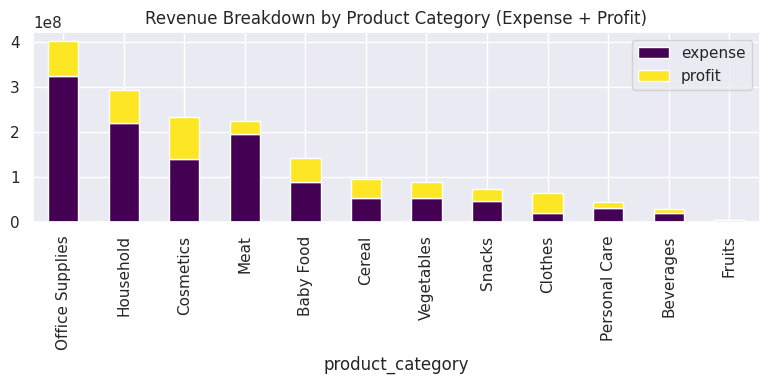

In [ ]:
# by catrogries
revenue_by_categories = (
    data.groupby("product_category")[["revenue", "expense", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

revenue_by_categories[["expense", "profit"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    colormap="viridis",
    title="Revenue Breakdown by Product Category (Expense + Profit)",
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

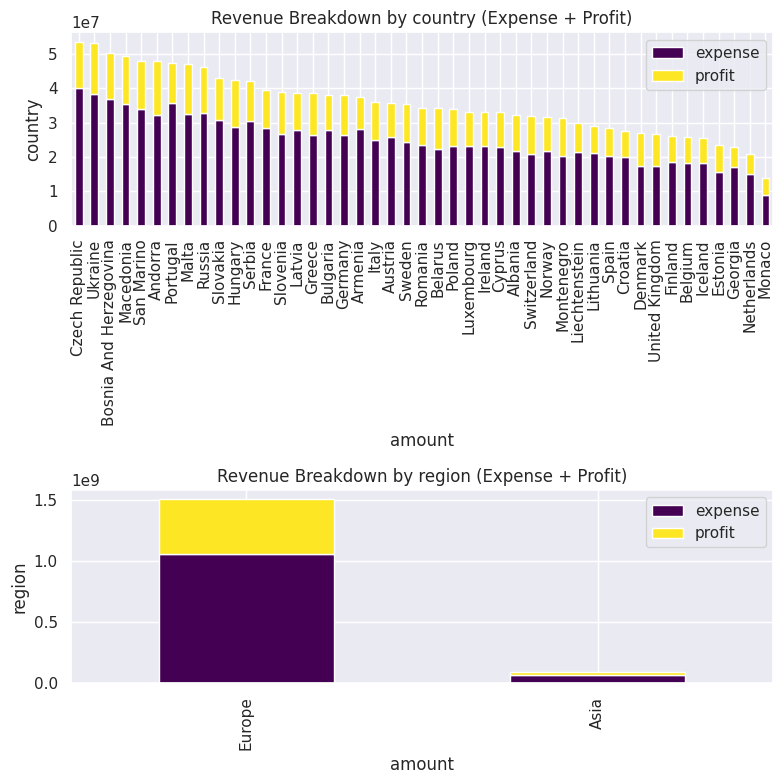

In [ ]:
# by country and region
revenue_by_country = (
    data.groupby("country_name")[["revenue", "expense", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)
revenue_by_region = (
    data.groupby("region")[["revenue", "expense", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

chart_data = [
    {
        "data": revenue_by_country,
        "ax": ax[0],
        "title": "Revenue Breakdown by country (Expense + Profit)",
        "x_label": "country",
        "y_label": "amount",
    },
    {
        "data": revenue_by_region,
        "ax": ax[1],
        "title": "Revenue Breakdown by region (Expense + Profit)",
        "x_label": "region",
        "y_label": "amount",
    },
]

for chart in chart_data:
    initial_data = chart["data"]
    data_ax = chart["ax"]
    initial_data[["expense", "profit"]].plot(
        kind="bar",
        stacked=True,
        colormap="viridis",
        ax=data_ax,
    )

    data_ax.set_title(chart["title"])
    data_ax.set_ylabel(chart["x_label"])
    data_ax.set_xlabel(chart["y_label"])
    data_ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

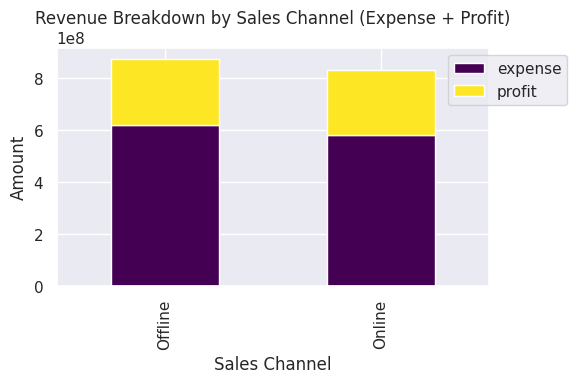

In [ ]:
# by sales channel
revenue_by_sales_channels = (
    data.groupby("sales_channel")[["revenue", "expense", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

ax = revenue_by_sales_channels[["expense", "profit"]].plot(
    kind="bar", stacked=True, figsize=(6, 4), colormap="viridis"
)

ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
plt.title("Revenue Breakdown by Sales Channel (Expense + Profit)")
plt.ylabel("Amount")
plt.xlabel("Sales Channel")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5.4 Product popularity

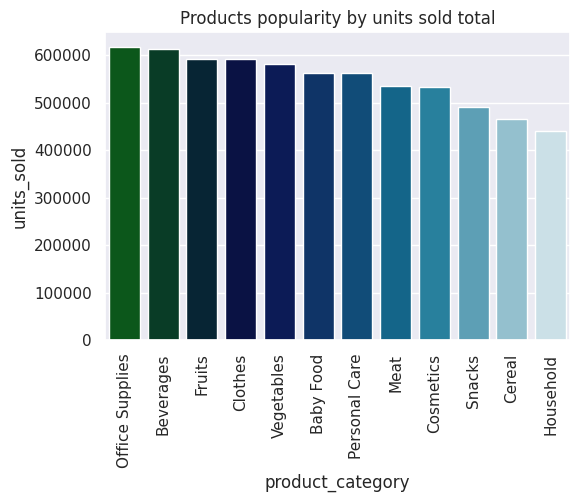

In [ ]:
# Product popularity is calculated by units_sold by category
popular_product_categories = (
    data.groupby("product_category")["units_sold"]
    .sum()
    .reset_index()
    .sort_values(by="units_sold", ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=popular_product_categories["product_category"],
    y=popular_product_categories["units_sold"],
    palette="ocean",
    hue=popular_product_categories["product_category"],
    # estimator='sum'
)
plt.xticks(rotation=90)
plt.title("Products popularity by units sold total")
plt.show()

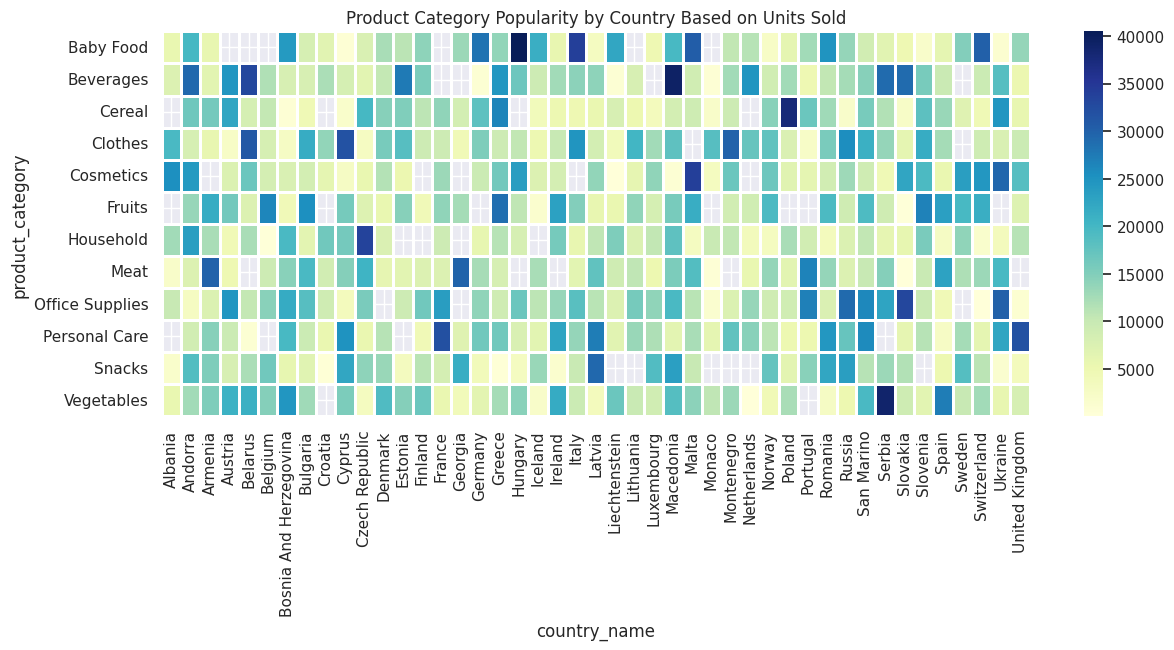

In [ ]:
# by geography (country)

country_pivot = pd.pivot_table(
    data,
    values="units_sold",
    columns="country_name",
    index="product_category",
    aggfunc="sum",
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    country_pivot,
    linewidths=1,
    cmap="YlGnBu",
)
plt.title("Product Category Popularity by Country Based on Units Sold")
plt.show()

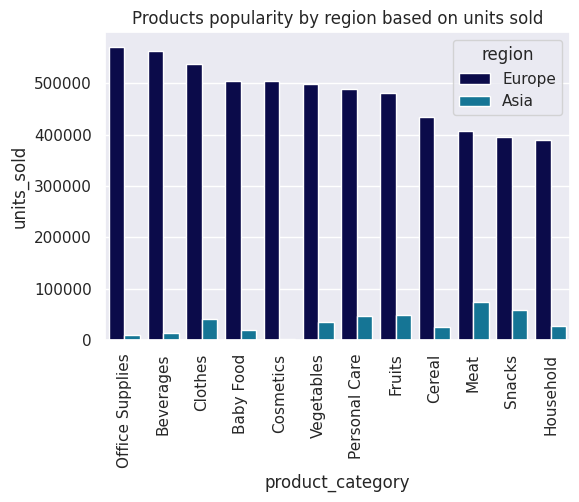

In [ ]:
# by geography (region)
popular_product_region = (
    data.groupby(["region", "product_category"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(by="units_sold", ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=popular_product_region["product_category"],
    y=popular_product_region["units_sold"],
    palette="ocean",
    hue=popular_product_region["region"],
)

plt.xticks(rotation=90)
plt.title("Products popularity by region based on units sold")
plt.show()

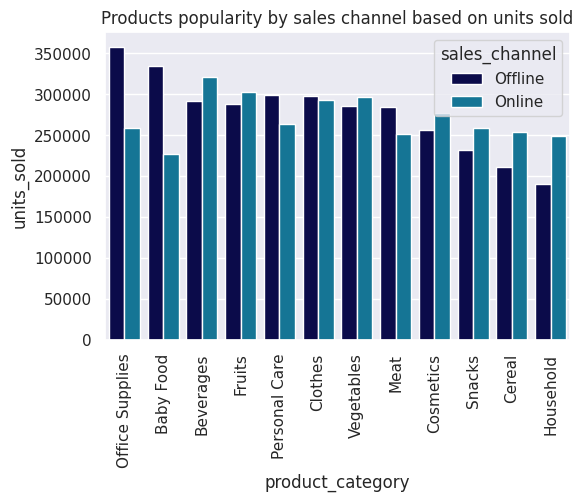

In [ ]:
# by sales_channel
popular_product_channel = (
    data.groupby(["sales_channel", "product_category"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values(by="units_sold", ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=popular_product_channel["product_category"],
    y=popular_product_channel["units_sold"],
    palette="ocean",
    hue=popular_product_channel["sales_channel"],
)

plt.xticks(rotation=90)
plt.title("Products popularity by sales channel based on units sold")
plt.show()

## 5.5 Order-to-ship interval

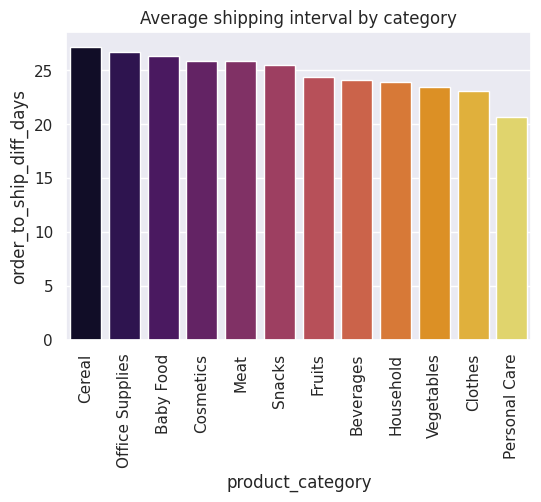

In [ ]:
# average shipping interval by categories
ship_int_by_cat = (
    data.groupby("product_category")["order_to_ship_diff_days"]
    .mean()
    .reset_index()
    .sort_values(by="order_to_ship_diff_days", ascending=False)
)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=ship_int_by_cat["product_category"],
    y=ship_int_by_cat["order_to_ship_diff_days"],
    palette="inferno",
    hue=ship_int_by_cat["product_category"],
)
plt.xticks(rotation=90)
plt.title("Average shipping interval by category")

plt.show()

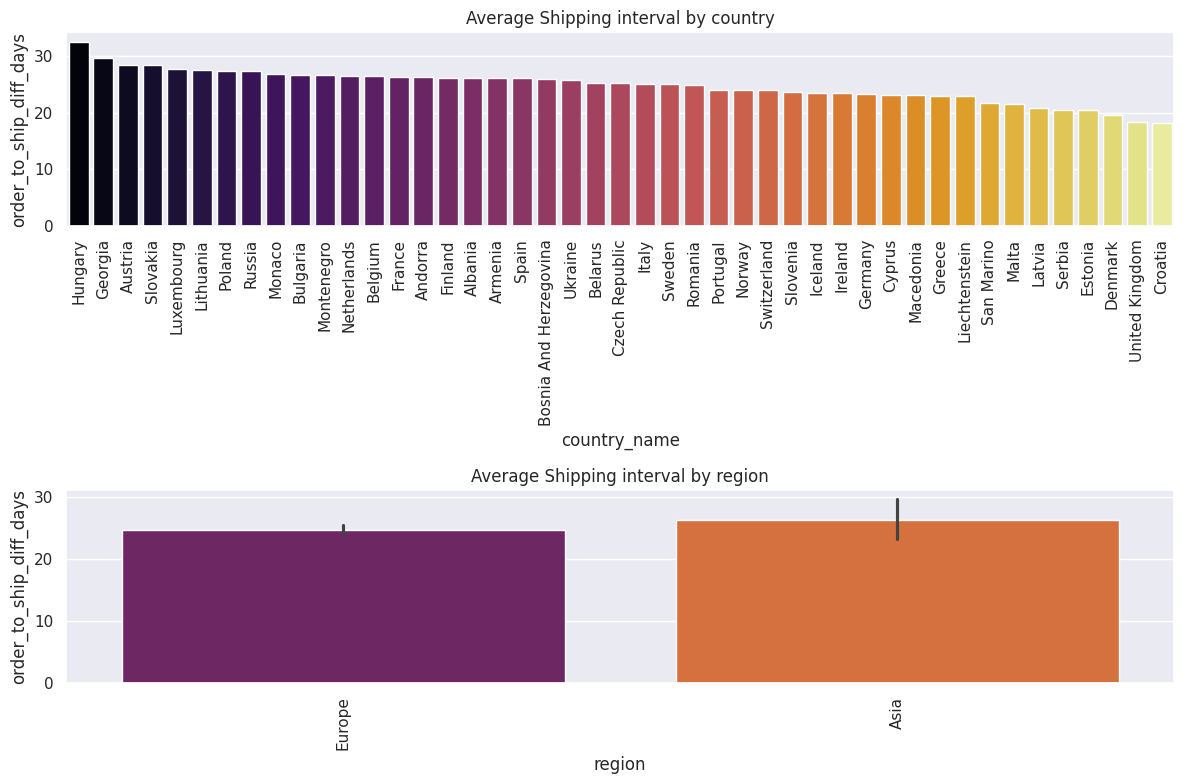

In [ ]:
# average shipping interval by countries
ship_int_by_geo = (
    data.groupby(["region", "country_name"])["order_to_ship_diff_days"]
    .mean()
    .reset_index()
    .sort_values(by="order_to_ship_diff_days", ascending=False)
)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

chart_data = [
    {
        "x": ship_int_by_geo["country_name"],
        "y": ship_int_by_geo["order_to_ship_diff_days"],
        "ax": ax[0],
        "title": "Average Shipping interval by country",
        "hue": ship_int_by_geo["country_name"],
    },
    {
        "x": ship_int_by_geo["region"],
        "y": ship_int_by_geo["order_to_ship_diff_days"],
        "ax": ax[1],
        "title": "Average Shipping interval by region",
        "hue": ship_int_by_geo["region"],
    },
]

for chart in chart_data:
    sns.barplot(
        x=chart["x"], y=chart["y"], palette="inferno", hue=chart["hue"], ax=chart["ax"]
    )

    chart["ax"].tick_params(axis="x", rotation=90)
    chart["ax"].set_title(chart["title"])

plt.tight_layout()
plt.show()

## 5.6 Profit and Shipping time relationship

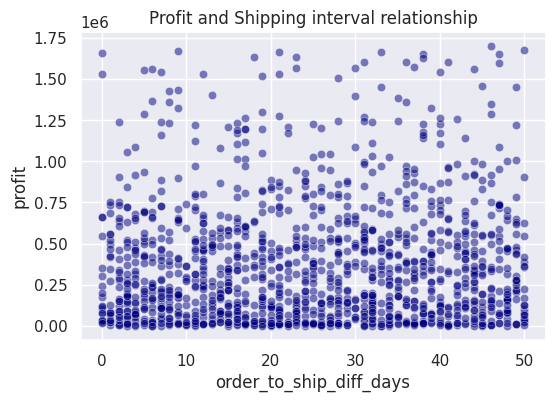

In [ ]:
# Analyze whether profit depends on the time required for shipping
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=data,
    y=data["profit"],
    x=data["order_to_ship_diff_days"],
    alpha=0.5,
    color="navy",
)
plt.title("Profit and Shipping interval relationship")
plt.show()

## 5.7 Sales dynamic

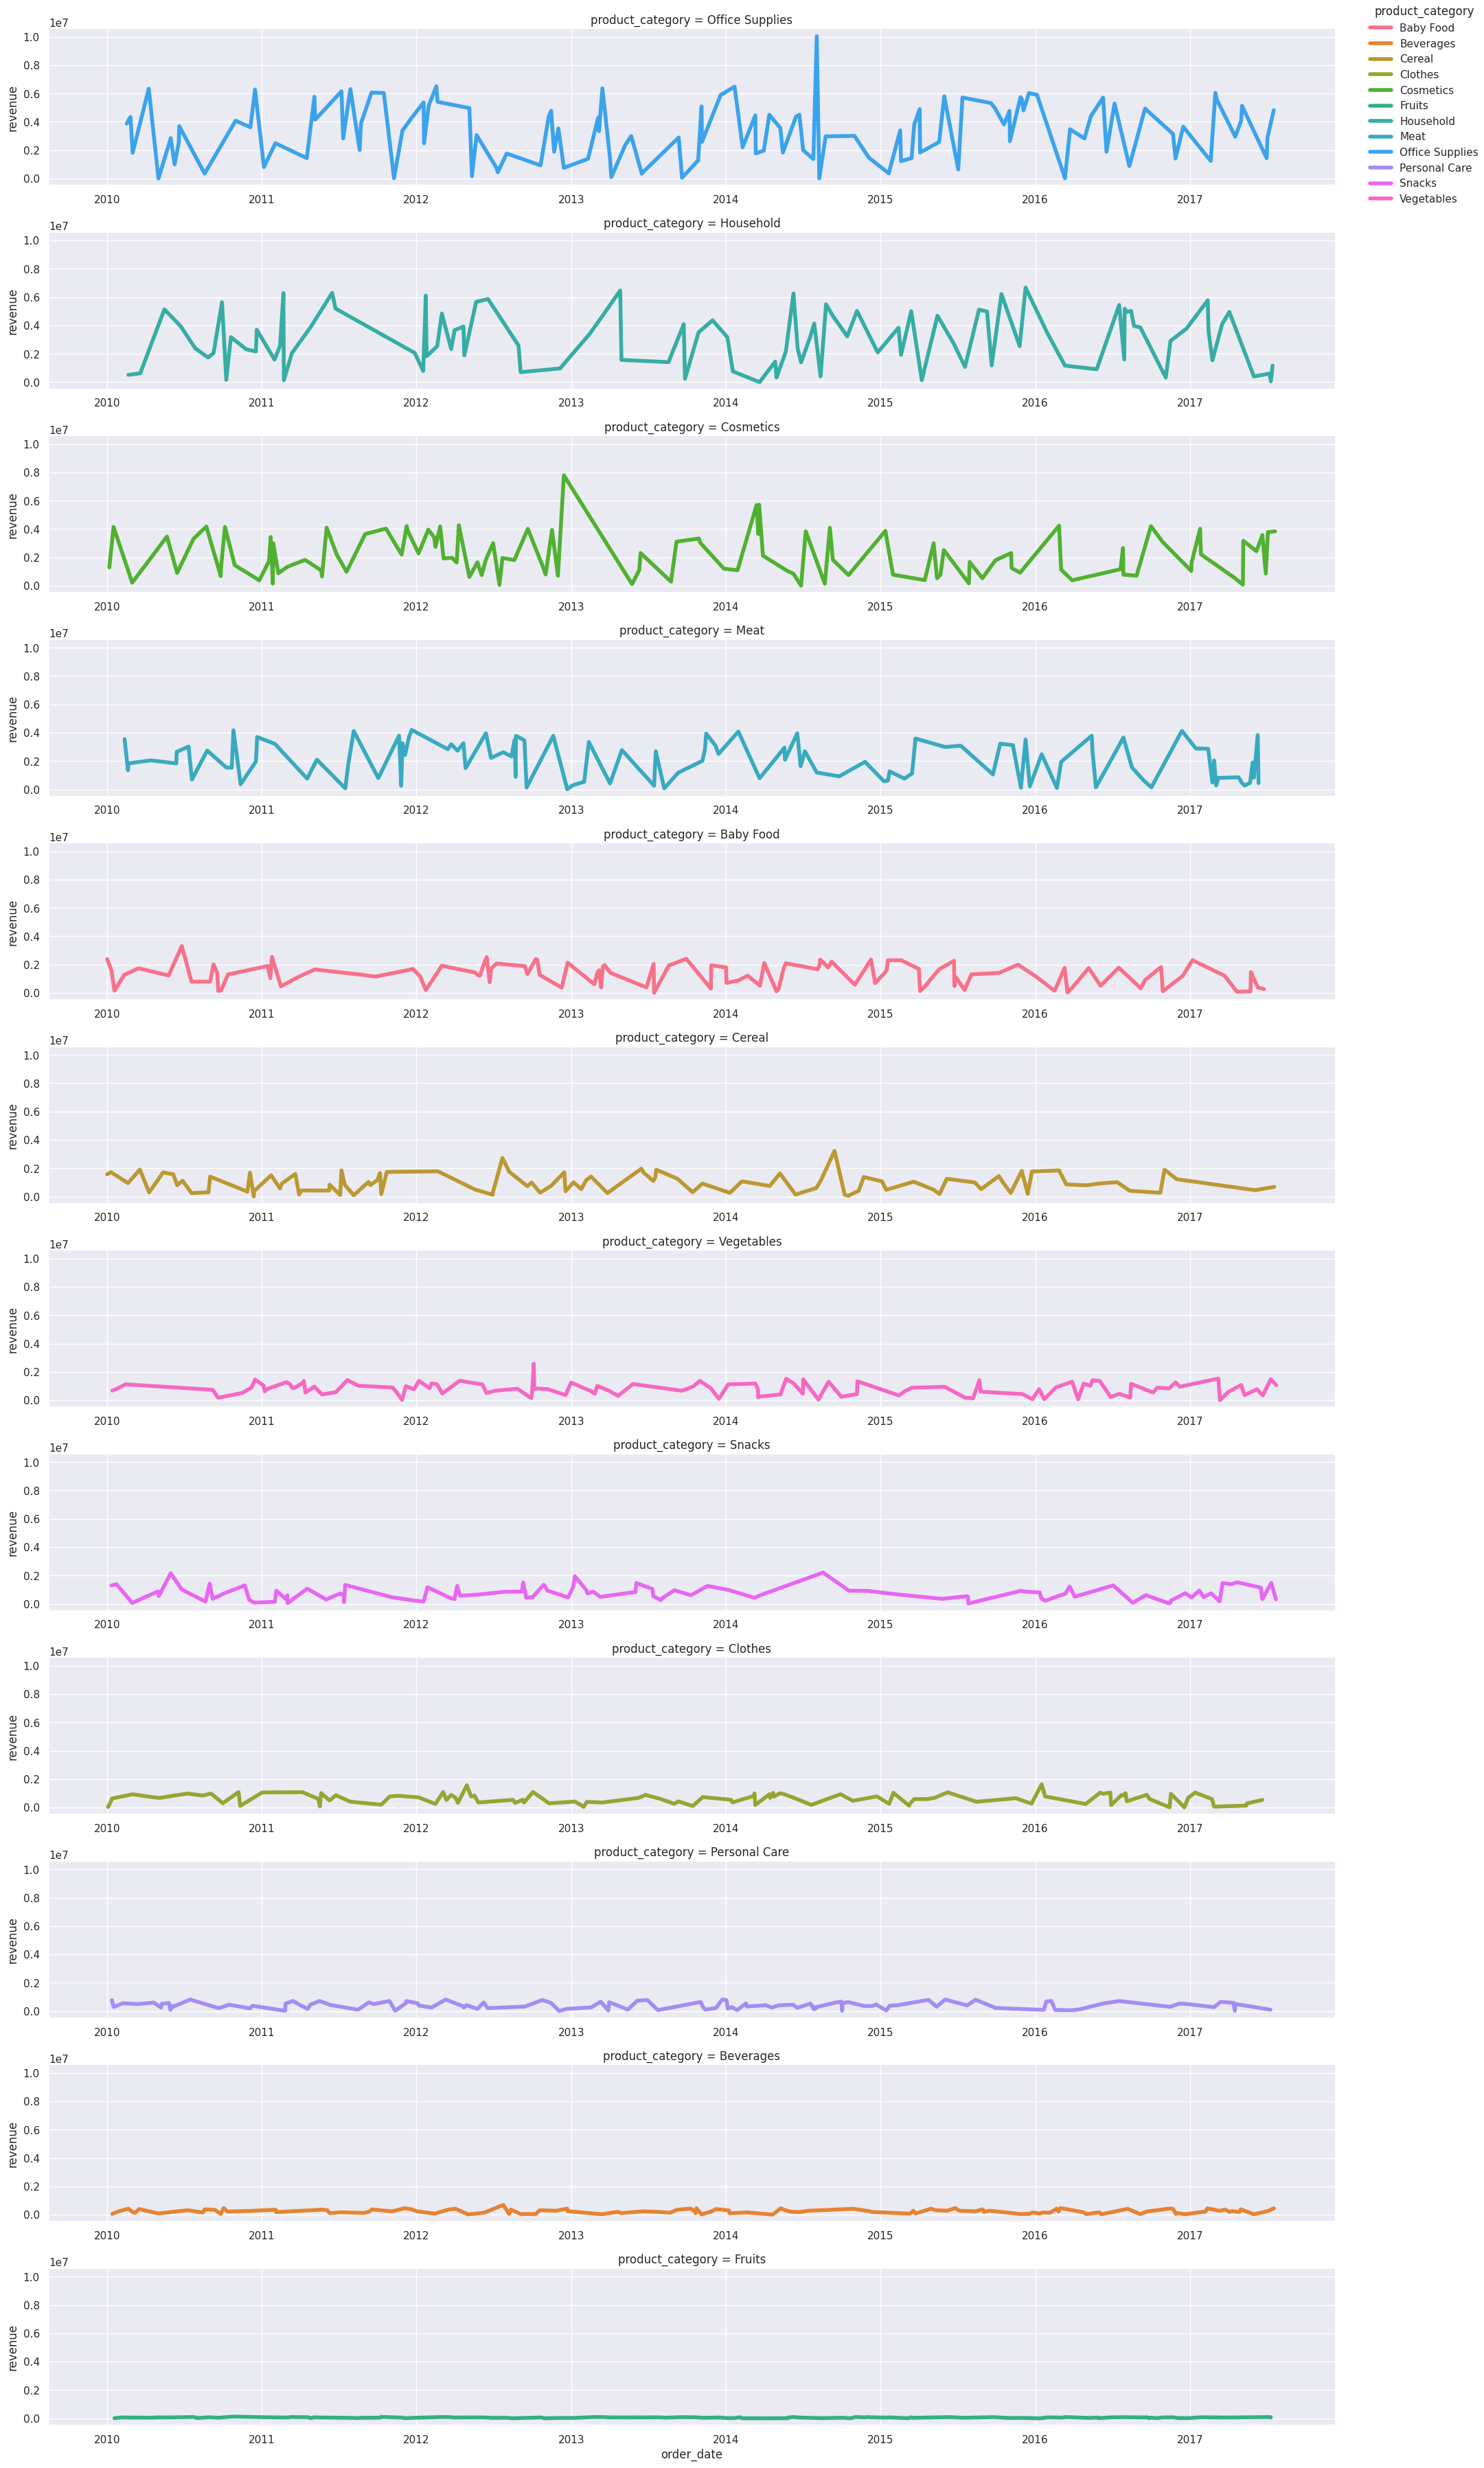

In [ ]:
# by categories
dynamic_grouped_by_cat = (
    data.groupby(["product_category", "order_date"])["revenue"].sum().reset_index()
)

order = (
    dynamic_grouped_by_cat.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .index
)

g = sns.relplot(
    kind="line",
    data=dynamic_grouped_by_cat,
    x="order_date",
    y="revenue",
    col="product_category",
    hue="product_category",
    height=3,
    aspect=6,
    col_wrap=1,
    col_order=order,
    linewidth=4,
)

g.legend.set_loc("upper right")
g.legend.set_bbox_to_anchor((1.1, 1))

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

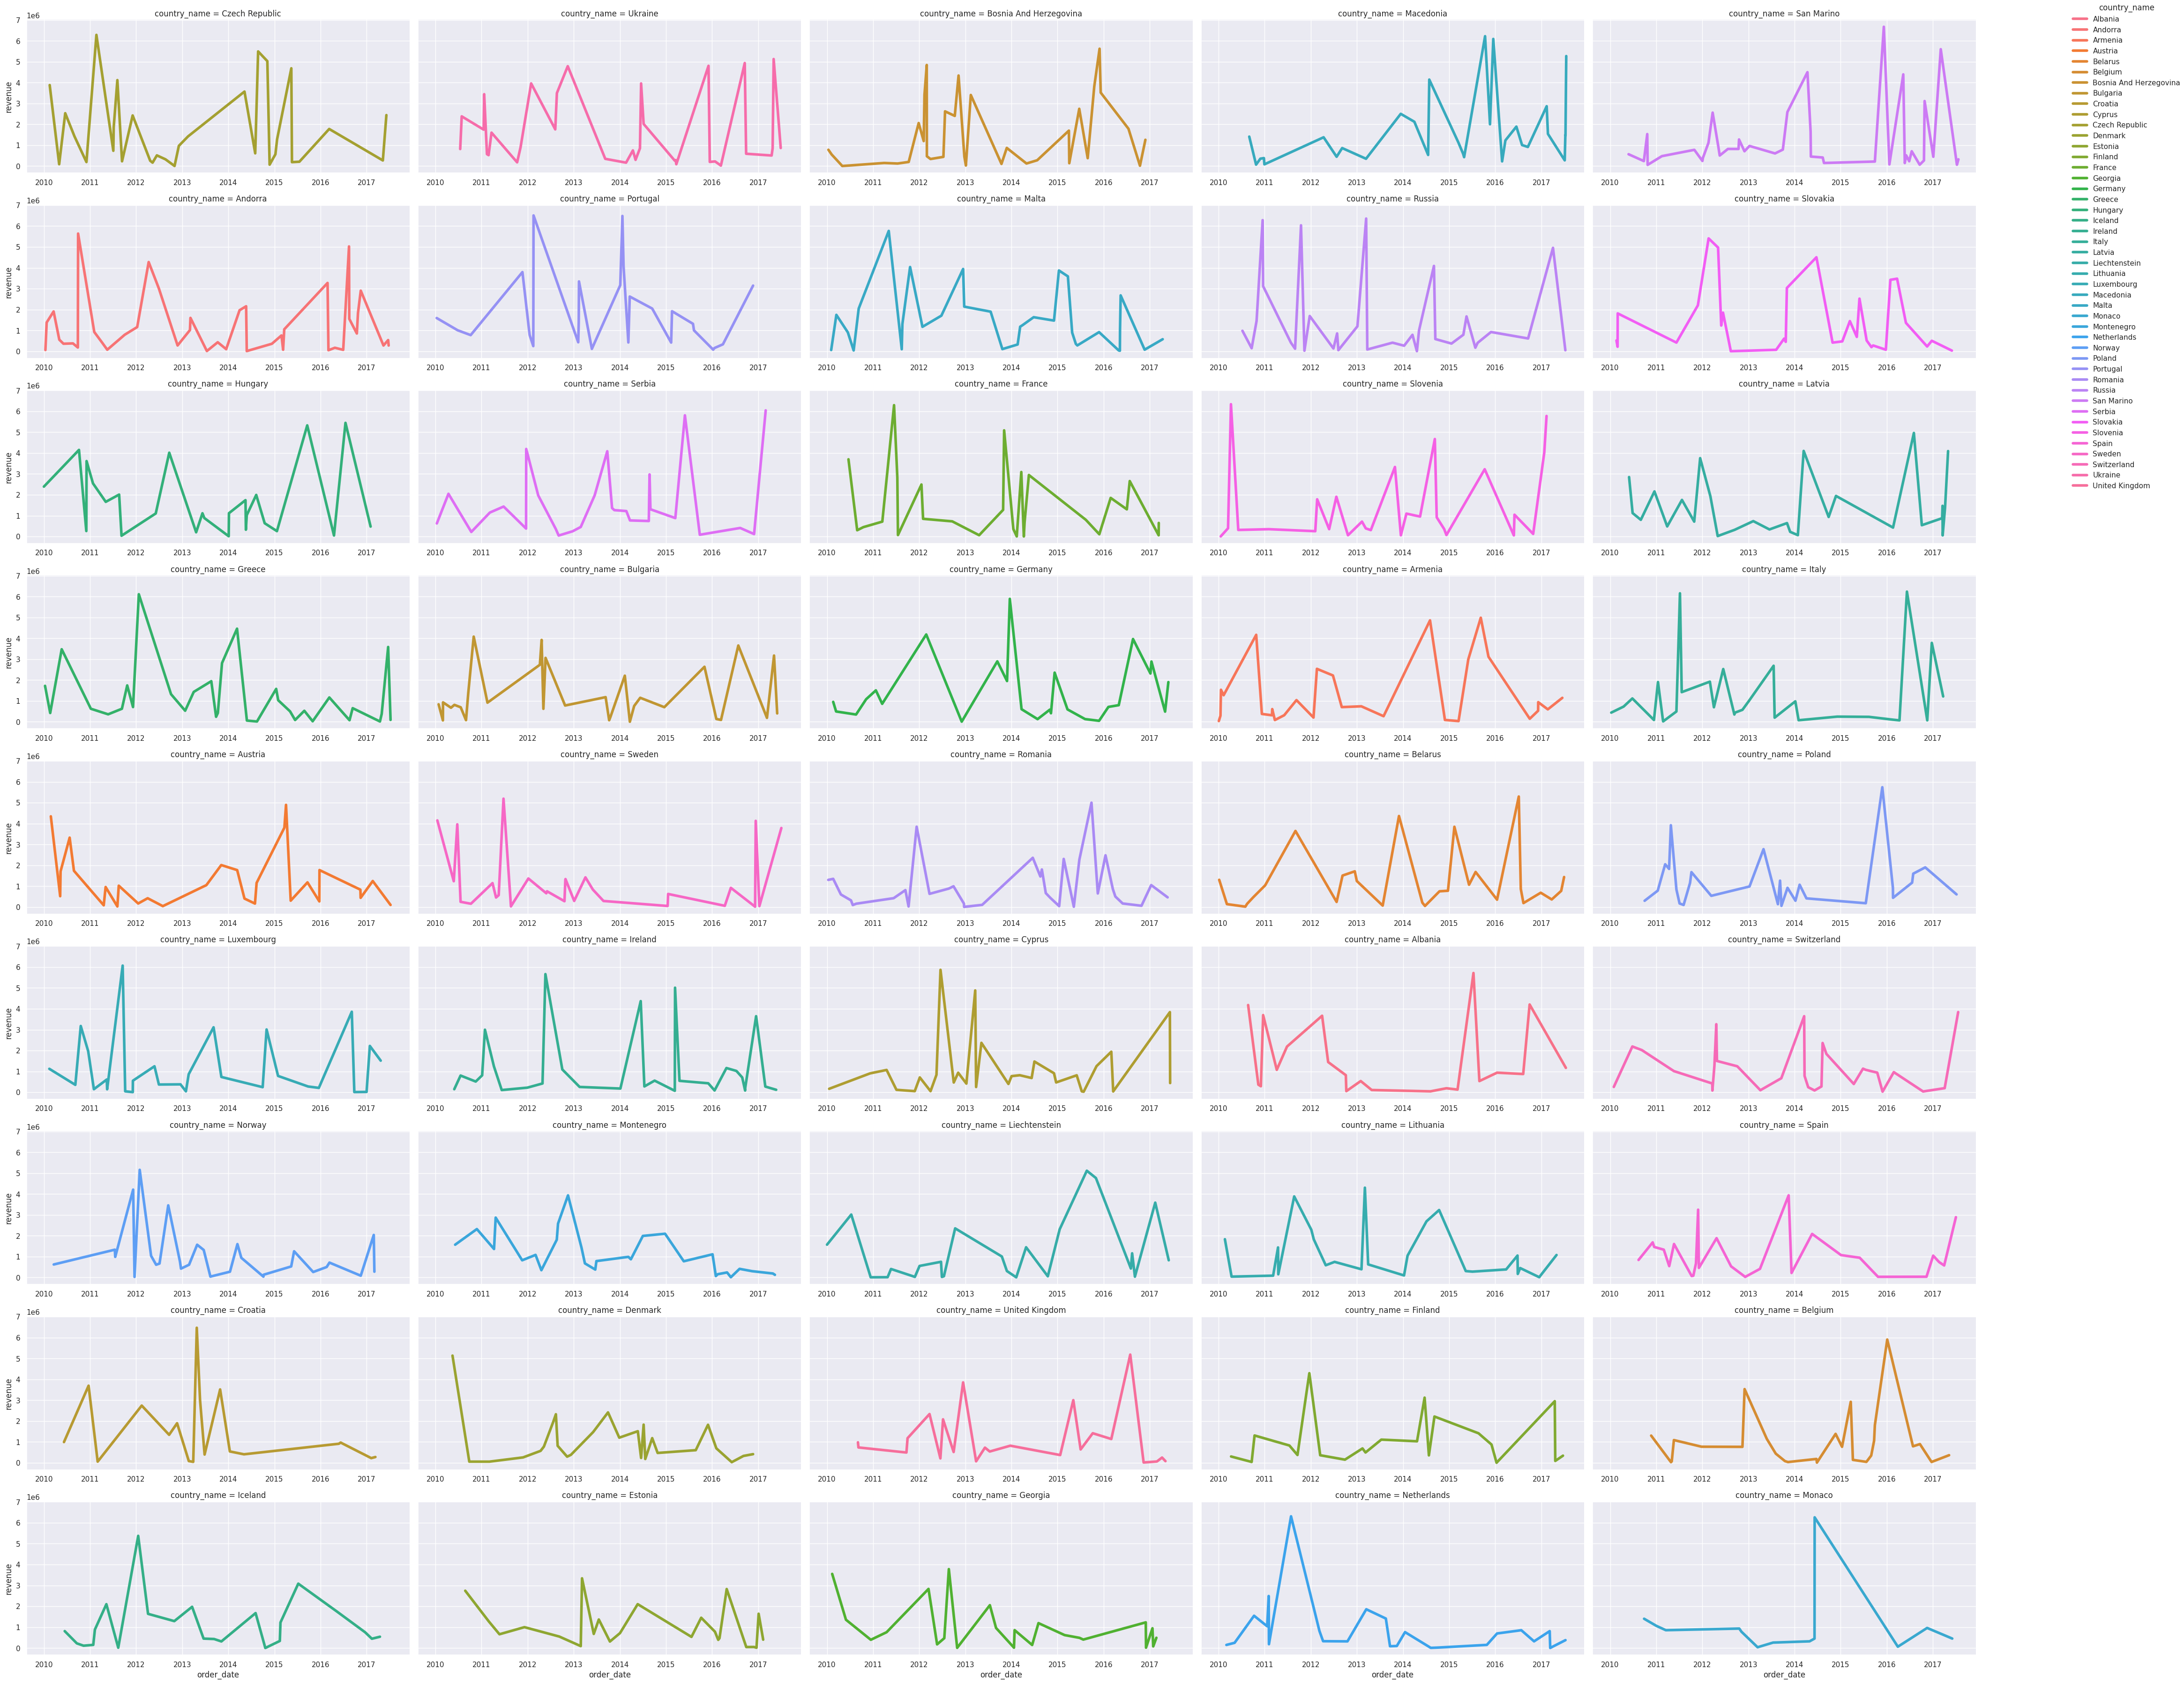

In [ ]:
# by countries
dynamic_grouped_by_country = (
    data.groupby(["country_name", "order_date"])["revenue"].sum().reset_index()
)

order = (
    dynamic_grouped_by_country.groupby("country_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .index
)

g = sns.relplot(
    kind="line",
    data=dynamic_grouped_by_country,
    x="order_date",
    y="revenue",
    col="country_name",
    hue="country_name",
    height=4,
    aspect=2,
    col_wrap=5,
    col_order=order,
    linewidth=4,
)

g.legend.set_loc("upper right")
g.legend.set_bbox_to_anchor((1.1, 1))

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

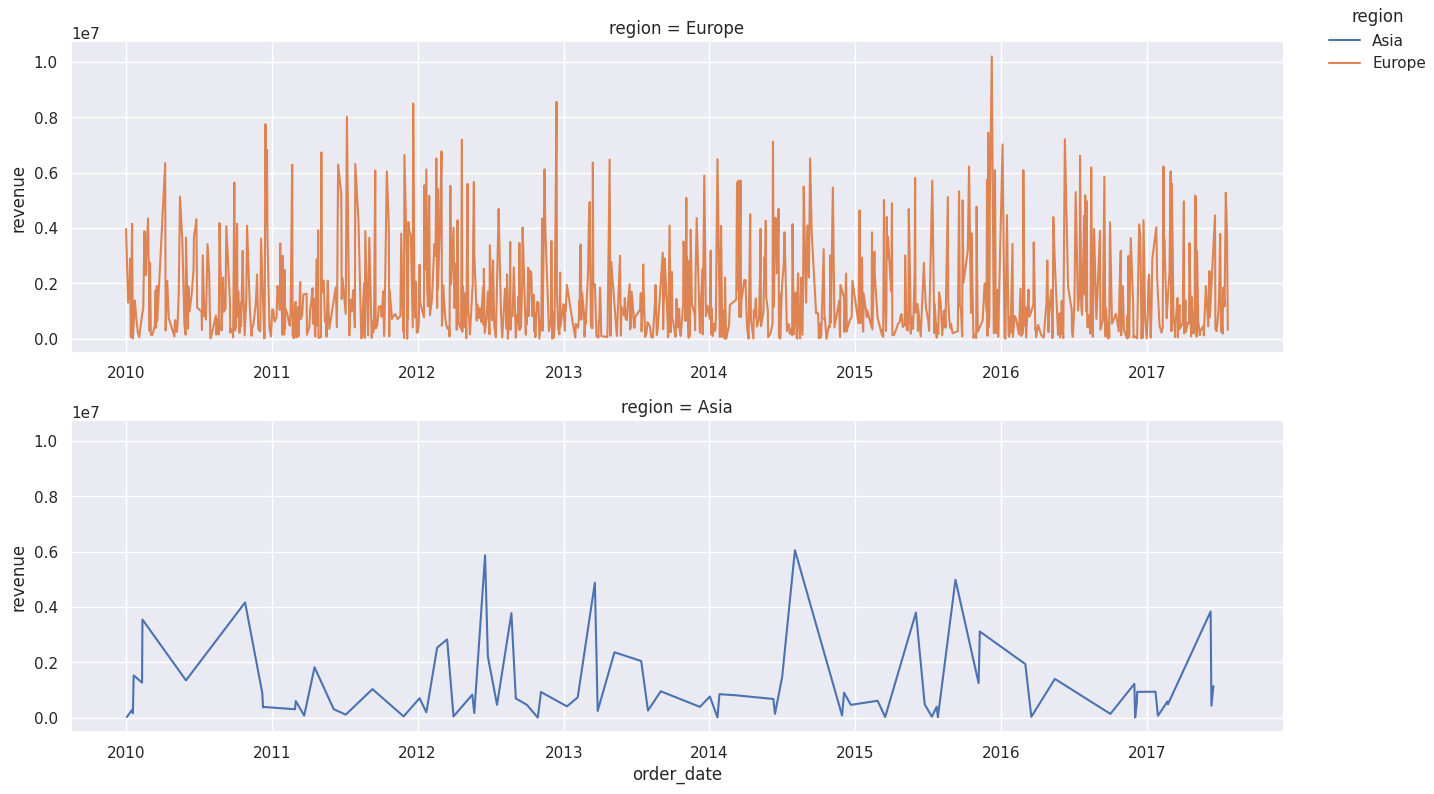

In [ ]:
# by regions
dynamic_grouped_by_region = (
    data.groupby(["region", "order_date"])["revenue"].sum().reset_index()
)

order = (
    dynamic_grouped_by_region.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 8))

g = sns.relplot(
    kind="line",
    data=dynamic_grouped_by_region,
    x="order_date",
    y="revenue",
    col="region",
    hue="region",
    col_wrap=1,
    height=4,
    aspect=3,
    col_order=order,
)

g.legend.set_loc("upper right")
g.legend.set_bbox_to_anchor((1.1, 1))

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.tight_layout()
plt.show()

## 5.8 Sales sesonality
Analyze product sales by days of the week. Can any products be considered seasonal?

/tmp/ipykernel_8823/3739705976.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_8823/3739705976.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


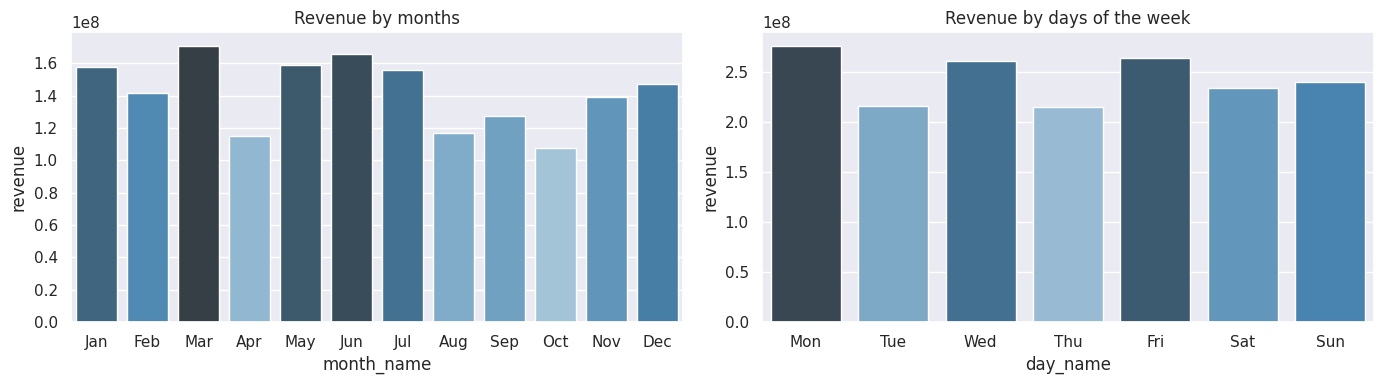

In [ ]:
data["day_name"] = data["order_date"].dt.day_name().str[:3]
data["month_name"] = data["order_date"].dt.month_name().str[:3]

day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# data sorted by revenue in asc order
revenue_month_sorted_asc = (
    data.groupby("month_name")["revenue"].sum().reset_index().sort_values(by="revenue")
)
revenue_days_sorted_asc = (
    data.groupby("day_name")["revenue"].sum().reset_index().sort_values(by="revenue")
)

# data_dict
figure, ax = plt.subplots(1, 2, figsize=(14, 4))

chart_dict = [
    {
        "data": revenue_month_sorted_asc,
        "order": month_order,
        "ax": ax[0],
        "x": "month_name",
        "y": "revenue",
        "title": "Revenue by months",
    },
    {
        "data": revenue_days_sorted_asc,
        "order": day_order,
        "ax": ax[1],
        "x": "day_name",
        "y": "revenue",
        "title": "Revenue by days of the week",
    },
]

# configure palettes, so that the highest revenue is the darkest
for chart in chart_dict:
    initial_data = chart["data"]
    initial_palette = sns.color_palette("Blues_d", n_colors=len(initial_data))
    color_mapping = dict(zip(initial_data[chart["x"]], initial_palette))
    color_order = [color_mapping[field] for field in chart["order"]]
    chart["color_order"] = color_order


for chart in chart_dict:
    sns.barplot(
        data=chart["data"],
        x=chart["x"],
        hue=None,
        y=chart["y"],
        palette=chart["color_order"],
        order=chart["order"],
        ax=chart["ax"],
        estimator="sum",
    )
    chart["ax"].set_title(chart["title"])

plt.tight_layout()
plt.show()

# 6. Interpretation & Recommendations

 *! **Caveat**: Geographical analysis should be percieved with caution, as there are missing values in country_code field.*

### Key company metrics (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=qvOTP_zIL0vA))

* **Total profit**: ~$501,84M

* **Covered countries**: 45 (*some missing country data – possible bias*)

* **Sales volume**: 1330 total orders, ~$6,58M total units sold

* **Average order size (avg revenue per order)**: ~$1,28M

* **Cumulative sales growth from 2010 year to 2017 year**: -34.76%

* **Median shipping interval**: ~24 days

**Note**: Despite high order volumes and wide global reach there is a tendency to sales decline in last years.



### Revenue / Expenses / Profit analysis (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=FmV3H79QUrdS))

* **Top category by revenue**: Office Supplies; **lowest**: Fruits.

* **Top countries**: Czech Republic & Ukraine; **lowest**: Monaco.

* **Regions**: Europe outperforms Asia in revenue and profit (could be expected if Europe is the main market.).

* **Channels**: Offline channel dominates revenue.

* **Patterns**: In most categories, countries, regions, and channels, expenses exceed profit.

**Note**: Review and optimize expenses to increase profit and company sustainability. Possible areas to investigate are: shipping costs, products' prize, ooperational expenses, etc.



### Product popularity (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=dasNxOK9VGqc))

* **Most sold category**: Office Supplies; **least sold**: Household. Some product categories are not purchased in some countries at all, [see the chart](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=V6cMp1jJVK44&line=8&uniqifier=1).

* **Regional preferences**:

   * Europe → Office Supplies, Beverages, Clothes

   * Asia → Meat, Snacks, Fruits, Personal Care

* **Channel split**: Some categories sell better offline, others online.

**Note**: Adjust products for each country based on local demand and popularity. Leverage online channel to optimize operational costs.


### Order-to-ship interval (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=dX2s8tvNRuHd))

* **Longest shipping**:
  * category: Cereal
  * country: Hungary

* **Shortest shipping**:
  * category: Personal Care
  * country: Croatia

* **Regional trend**: Europe ships faster than Asia.

**Note**: Optimize shipping in longest-shipping categories and countries in terms of cost if possible.



### Profit and shipping time relationship (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=McqFdt_bMrpP))

No correlation. Profit is likely driven by pricing, demand, or cost, not delivery speed.



### Sales dynamic & seasonality (see detailed analysis [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=6CDpFBSFM17k))

* **Category fluctuations**: Popular categories show peaks (e.g., Office Supplies mid-2014, Cosmetics in 2013). Less popular categories don't have such fluctuations over time. See detailed chart [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=Nj1nf0qTUqpP&line=32&uniqifier=1)

* **Country patterns**: Peak years vary by country, no synchronized global spikes. See detailed chart [here](https://colab.research.google.com/drive/1dZhfXUtXkVdSnmR6h15k6R3B4Uqmb45u#scrollTo=cazc8MfvaCUV&line=6&uniqifier=1).

* **Seasonality**:

  * Best month: March

  * Worst month: October

  * Best days: Monday, Friday

  * Worst day: Thursday

**Note**: Plan workload and stock accounting for seasonality.

